In [6]:
import sys
sys.path.append('../src')

import torch
from model import build_model
from gradcam import visualize_gradcam
import os

# Load model
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = build_model()
model.load_state_dict(torch.load('../outputs/models/best_model.pth', map_location=device))
model.eval()
model = model.to(device)

print(f"Model loaded on: {device}")

Model loaded on: mps


In [7]:
import pandas as pd
import os

# Load a sample image from the dataset
df = pd.read_csv('../data/archive/valid.csv')

# Find an image with positive Pleural Effusion
sample = df[df['Pleural Effusion'] == 1.0].iloc[0]
img_path = os.path.join('..', 'data', 'archive', sample['Path'].replace('CheXpert-v1.0-small/', ''))

print(f"Image: {img_path}")
print(f"Labels: {sample[['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Pleural Effusion']].to_dict()}")

Image: ../data/archive/valid/patient64545/study1/view1_frontal.jpg
Labels: {'Atelectasis': 1.0, 'Cardiomegaly': 0.0, 'Consolidation': 0.0, 'Edema': 0.0, 'Pleural Effusion': 1.0}


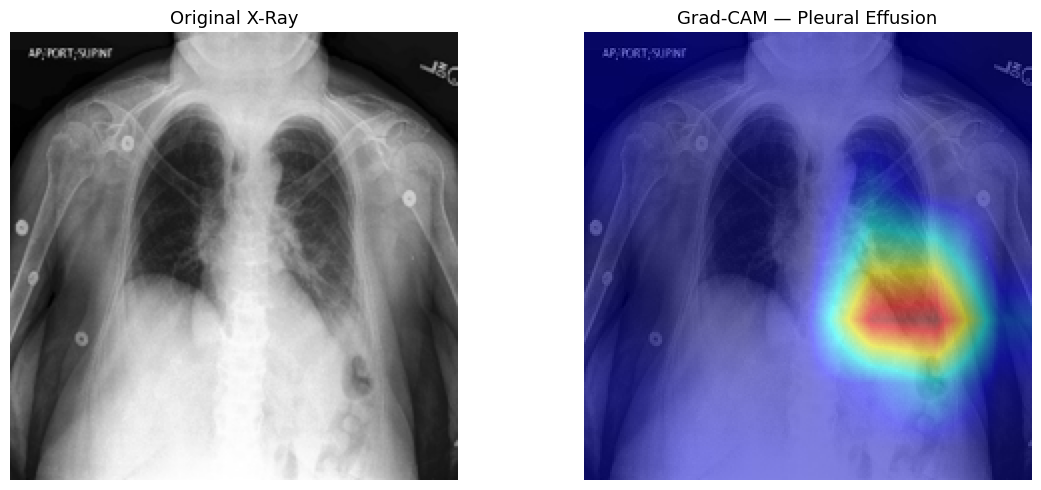

In [3]:
# Generate Grad-CAM for Pleural Effusion (index 4)
visualize_gradcam(
    image_path=img_path,
    class_idx=4,  # Pleural Effusion
    model=model,
    device=device,
    save_path='../outputs/gradcam/pleural_effusion.png'
)

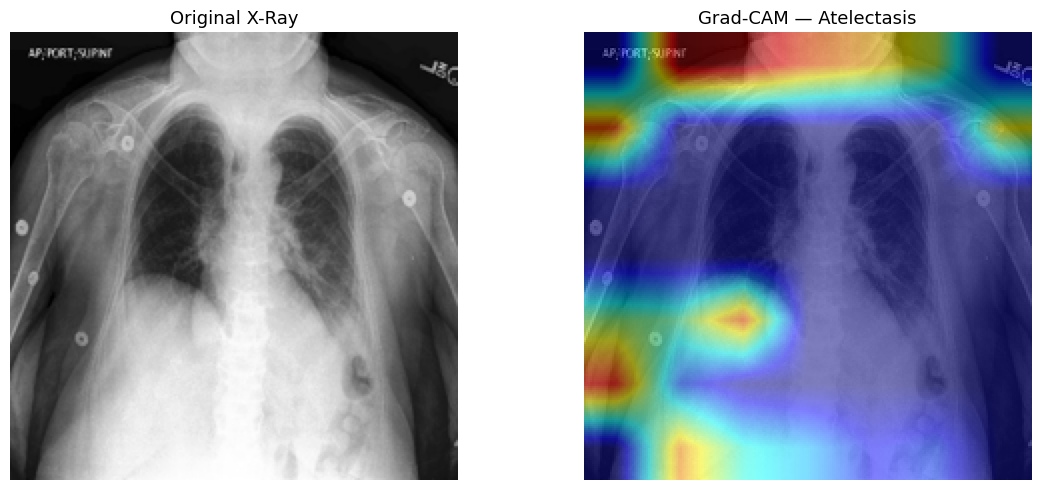

In [4]:
# Generate Grad-CAM for Atelectasis (index 0)
visualize_gradcam(
    image_path=img_path,
    class_idx=0,  # Atelectasis
    model=model,
    device=device,
    save_path='../outputs/gradcam/atelectasis.png'
)

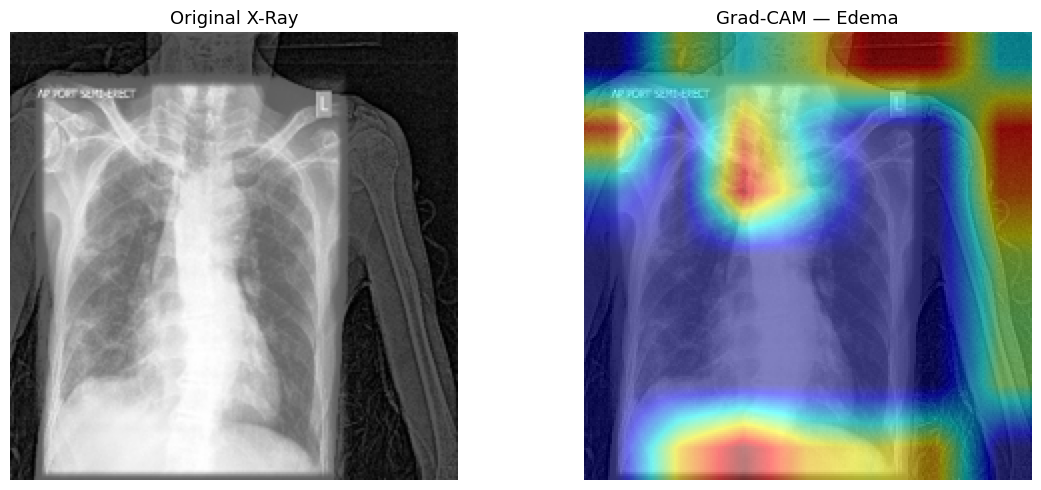

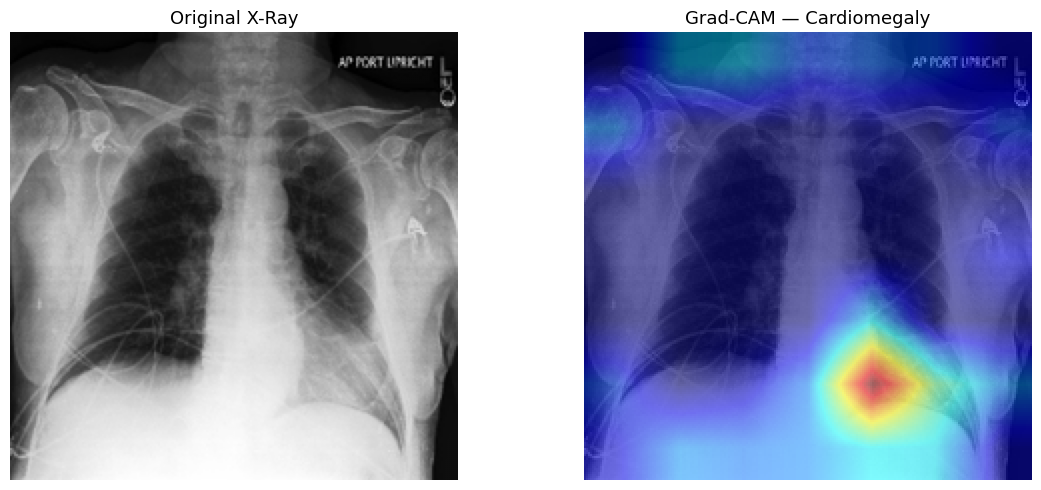

In [5]:
# Grad-CAM for Edema (index 3) and Cardiomegaly (index 1)
# Find image with positive Edema
sample_edema = df[df['Edema'] == 1.0].iloc[0]
img_path_edema = os.path.join('..', 'data', 'archive', sample_edema['Path'].replace('CheXpert-v1.0-small/', ''))

visualize_gradcam(
    image_path=img_path_edema,
    class_idx=3,  # Edema
    model=model,
    device=device,
    save_path='../outputs/gradcam/edema.png'
)

# Find image with positive Cardiomegaly
sample_cardio = df[df['Cardiomegaly'] == 1.0].iloc[0]
img_path_cardio = os.path.join('..', 'data', 'archive', sample_cardio['Path'].replace('CheXpert-v1.0-small/', ''))

visualize_gradcam(
    image_path=img_path_cardio,
    class_idx=1,  # Cardiomegaly
    model=model,
    device=device,
    save_path='../outputs/gradcam/cardiomegaly.png'
)